In [1]:
# !pip install ta
# !pip install yfinance
# !pip install statsmodels

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ta.momentum import RSIIndicator
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from statsmodels.tsa.arima.model import ARIMA

# 1. Data Collection

In [3]:
# initializing stock variable
ticker = "GOOG"

# getting and displaying the data of 11 years of GOOG's stock history
data = yf.download(ticker, start="2014-01-01", end="2026-01-01")

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2014-01-02,27.498323,27.612703,27.378263,27.556132,73129082
2014-01-03,27.297728,27.592444,27.295998,27.544767,66917888
2014-01-06,27.602079,27.640122,27.333301,27.495606,71037271
2014-01-07,28.134203,28.154708,27.696947,27.791809,102486711
2014-01-08,28.192753,28.343200,27.996604,28.310590,90036218


In [4]:
data.columns

MultiIndex([( 'Close', 'GOOG'),
            (  'High', 'GOOG'),
            (   'Low', 'GOOG'),
            (  'Open', 'GOOG'),
            ('Volume', 'GOOG')],
           names=['Price', 'Ticker'])

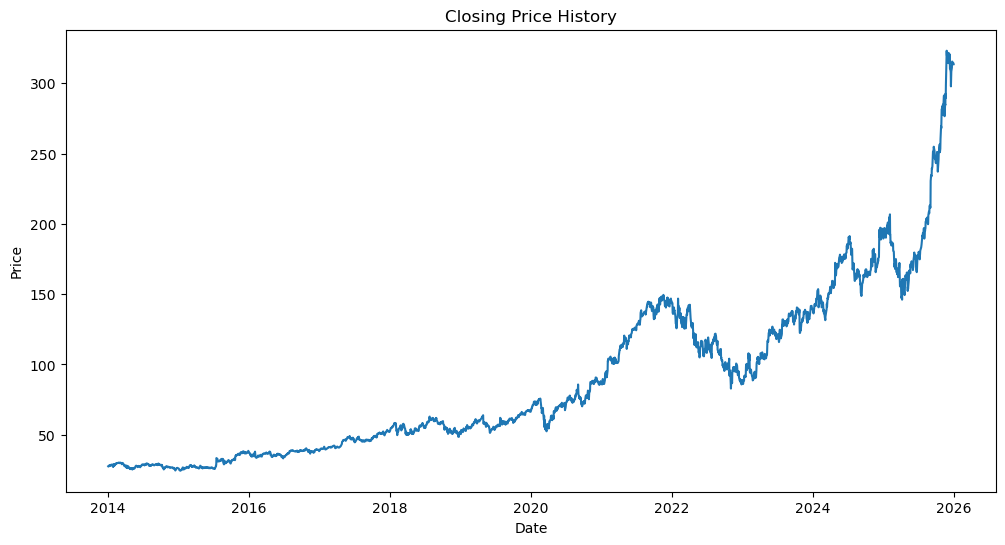

In [5]:
# display the closing price history
plt.figure(figsize=(12,6))

plt.plot(data["Close"])

plt.title("Closing Price History")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

# 2. Feature Engineering

In [6]:
# change in close price each day
data["Price_Change"] = data["Close"].diff()

# 20 day moving avg
data["SMA20"] = data["Close"].rolling(window=20).mean()

# 50 day moving avg
data["SMA50"] = data["Close"].rolling(window=50).mean()

# pct change between rows, today and yesterday
data["Daily_Return"] = data["Close"].pct_change()

# standard deviation of last 20 days, higher value = greater volatility
data["Volatility_20"] = data["Daily_Return"].rolling(window=20).std()

# yesterday's price to help predict tomorrow's price
data["Lag1_Close"] = data["Close"].shift(1)

# RSI > 70: overbought
# RSI < 30: oversold
rsi = RSIIndicator(close=data["Close"].squeeze(), window=14)

data["RSI_14"] = rsi.rsi()

# 3. Prediction Targets

In [7]:
# Define target: shift Close price to align today's data with tomorrow's outcome
data["Tomorrow_Close"] = data["Close"].shift(-1)

# Tomorrow > Today: 1 (price went UP)
# Tomorrow <= Today: 0 (price went DOWN)
data["Direction"] = (data["Tomorrow_Close"] > data["Close"].squeeze()).astype(int)

In [8]:
# removing null values, rows contain null values because:
# SMA20 needs 20 days
# SMA50 needs 50 days
# RSI needs 14 days
data = data.dropna()

In [9]:
data.head(10)

Price,Close,High,Low,Open,Volume,Price_Change,SMA20,SMA50,Daily_Return,Volatility_20,Lag1_Close,RSI_14,Tomorrow_Close,Direction
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG,,,,,,,,,
Date,,,,,,,,,,,,,,
2014-03-14,28.972651,29.419049,28.965980,29.199678,92099924,-0.401684,29.845237,28.917411,-0.013675,0.007145,29.374334,41.274426,29.449430,1
2014-03-17,29.449430,29.572209,29.103824,29.131987,86808163,0.476780,29.832020,28.956433,0.016456,0.008132,28.972651,49.471701,29.922758,1
2014-03-18,29.922758,29.929429,29.473149,29.512922,72872123,0.473328,29.832490,29.008933,0.016073,0.008805,29.449430,56.033102,29.626062,0
2014-03-19,29.626062,29.940789,29.506494,29.936095,64757822,-0.296696,29.828673,29.049413,-0.009915,0.008948,29.922758,51.517164,29.574430,0
2014-03-20,29.574430,29.881993,29.529963,29.643353,67640587,-0.051632,29.820088,29.078218,-0.001743,0.008948,29.626062,50.750621,29.225616,0
2014-03-21,29.225616,29.882493,29.211042,29.800475,128821050,-0.348814,29.794458,29.098875,-0.011794,0.009313,29.574430,45.793304,28.605301,0
2014-03-24,28.605301,29.271563,28.309347,29.254024,121939352,-0.620316,29.727041,29.112556,-0.021225,0.010152,29.225616,38.576686,28.624817,1
2014-03-25,28.624817,28.899524,28.335289,28.804662,96769361,0.019516,29.651348,29.126657,0.000682,0.009985,28.605301,38.902909,27.963991,0


In [10]:
data.describe()

Price,Close,High,Low,Open,Volume,Price_Change,SMA20,SMA50,Daily_Return,Volatility_20,Lag1_Close,RSI_14,Tomorrow_Close,Direction
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG,,,,,,,,,
count,2968.000000,2968.000000,2968.000000,2968.000000,2.968000e+03,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000
mean,89.223932,90.152994,88.253985,89.172637,3.080534e+07,0.096009,88.321188,86.936051,0.000958,0.016470,89.127923,54.410087,89.319824,0.536388
std,58.519057,59.193919,57.818725,58.490691,1.602053e+07,1.987103,57.127581,54.994546,0.017871,0.007184,58.383213,11.636009,58.653324,0.498758
min,24.360073,24.529514,24.113282,24.463936,1.584340e+05,-14.344009,25.322609,25.747296,-0.111008,0.002915,24.360073,24.077307,24.360073,0.000000
25%,40.854218,41.024948,40.684979,40.806981,2.099485e+07,-0.469393,40.403831,39.928708,-0.007289,0.011174,40.840078,45.916402,40.868846,0.000000
50%,66.032879,66.581867,65.304107,65.924022,2.678372e+07,0.061325,65.012169,63.812097,0.001093,0.015128,65.832775,54.725691,66.231499,1.000000
75%,131.058029,132.451463,129.586348,131.023063,3.549650e+07,0.694293,132.028306,130.786931,0.009931,0.020493,131.016750,62.782553,131.128078,1.000000
max,323.201294,328.224474,319.546256,326.356983,2.232980e+08,19.067078,314.233405,295.855741,0.160524,0.055626,323.201294,89.071270,323.201294,1.000000


In [11]:
data.columns

MultiIndex([(         'Close', 'GOOG'),
            (          'High', 'GOOG'),
            (           'Low', 'GOOG'),
            (          'Open', 'GOOG'),
            (        'Volume', 'GOOG'),
            (  'Price_Change',     ''),
            (         'SMA20',     ''),
            (         'SMA50',     ''),
            (  'Daily_Return',     ''),
            ( 'Volatility_20',     ''),
            (    'Lag1_Close',     ''),
            (        'RSI_14',     ''),
            ('Tomorrow_Close',     ''),
            (     'Direction',     '')],
           names=['Price', 'Ticker'])

# 4. Feature Engineering

In [12]:
data.loc[:, "Return_Lag1"] = data["Daily_Return"].shift(1)
data.loc[:, "Return_Lag2"] = data["Daily_Return"].shift(2)
data.loc[:, "Return_Lag3"] = data["Daily_Return"].shift(3)
data.loc[:, "SMA_diff"] = data["SMA20"] - data["SMA50"]

C:\Users\denim\AppData\Local\Temp\ipykernel_19884\1021510913.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, "Return_Lag1"] = data["Daily_Return"].shift(1)
C:\Users\denim\AppData\Local\Temp\ipykernel_19884\1021510913.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, "Return_Lag2"] = data["Daily_Return"].shift(2)
C:\Users\denim\AppData\Local\Temp\ipykernel_19884\1021510913.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

In [13]:
data.loc[:, "Lag2_Close"] = data["Close"].shift(2)
data.loc[:, "Lag3_Close"] = data["Close"].shift(3)
data.loc[:, "Lag5_Close"] = data["Close"].shift(5)
data = data.dropna()

C:\Users\denim\AppData\Local\Temp\ipykernel_19884\3950296242.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, "Lag2_Close"] = data["Close"].shift(2)
C:\Users\denim\AppData\Local\Temp\ipykernel_19884\3950296242.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, "Lag3_Close"] = data["Close"].shift(3)
C:\Users\denim\AppData\Local\Temp\ipykernel_19884\3950296242.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

In [14]:
# predictor variables used by the models
features = [
    "Close",
    "High",
    "Low",
    "Open",
    "Volume",
    "Price_Change",
    "SMA20",
    "SMA50",
    "SMA_diff",
    "Daily_Return",
    "Volatility_20",
    "Lag1_Close",
    "Lag2_Close",
    "Lag3_Close",
    "Lag5_Close",
    "RSI_14",
    "Return_Lag1",
    "Return_Lag2",
    "Return_Lag3"
]

# feature matrix
X = data[features].copy()

# Target variable for price prediction(regression)
y_price = data["Tomorrow_Close"]

# Target variable for price direction prediction(classification)
y_direction = data["Direction"]

In [15]:
X.columns = ["_".join(col).strip() if isinstance(col, tuple) else col for col in X.columns] 

In [16]:
X.columns

Index(['Close_GOOG', 'High_GOOG', 'Low_GOOG', 'Open_GOOG', 'Volume_GOOG',
       'Price_Change_', 'SMA20_', 'SMA50_', 'SMA_diff_', 'Daily_Return_',
       'Volatility_20_', 'Lag1_Close_', 'Lag2_Close_', 'Lag3_Close_',
       'Lag5_Close_', 'RSI_14_', 'Return_Lag1_', 'Return_Lag2_',
       'Return_Lag3_'],
      dtype='object')

# 5. Splitting data for training and testing

In [17]:
# Splitting data for price
# shuffle off(time series data) so it doesn't train on new data and test on old, 
# Training size: 80%, Testing size: 20%
X_train_price, X_test_price, y_train_price, y_test_price = train_test_split(
    X,
    y_price,
    test_size = 0.2,
    shuffle = False
)
X_train_price.shape, X_test_price.shape, y_train_price.shape, y_test_price.shape

((2370, 19), (593, 19), (2370,), (593,))

In [18]:
# Splitting data for direction following the same rules as above
X_train_dir, X_test_dir, y_train_dir, y_test_dir = train_test_split(
    X,
    y_direction,
    test_size = 0.2,
    shuffle = False
)
X_train_dir.shape, X_test_dir.shape, y_train_dir.shape, y_test_dir.shape

((2370, 19), (593, 19), (2370,), (593,))

# 6. Linear Regression

In [19]:
lr_model = LinearRegression()

lr_model.fit(X_train_price, y_train_price)

LinearRegression()

In [20]:
lr_predictions = lr_model.predict(X_test_price)

In [21]:
mae = mean_absolute_error(y_test_price, lr_predictions)

rmse = np.sqrt(mean_squared_error(y_test_price, lr_predictions))

lr_r2 = score = r2_score(y_test_price, lr_predictions)

print(f"Linear Regression r2 score: {lr_r2:.2%}")
print(f"Linear Regression MAE: {mae:.2f}")
print(f"Linear Regression RMSE: {rmse:.2f}")

Linear Regression r2 score: 99.41%
Linear Regression MAE: 2.42
Linear Regression RMSE: 3.47


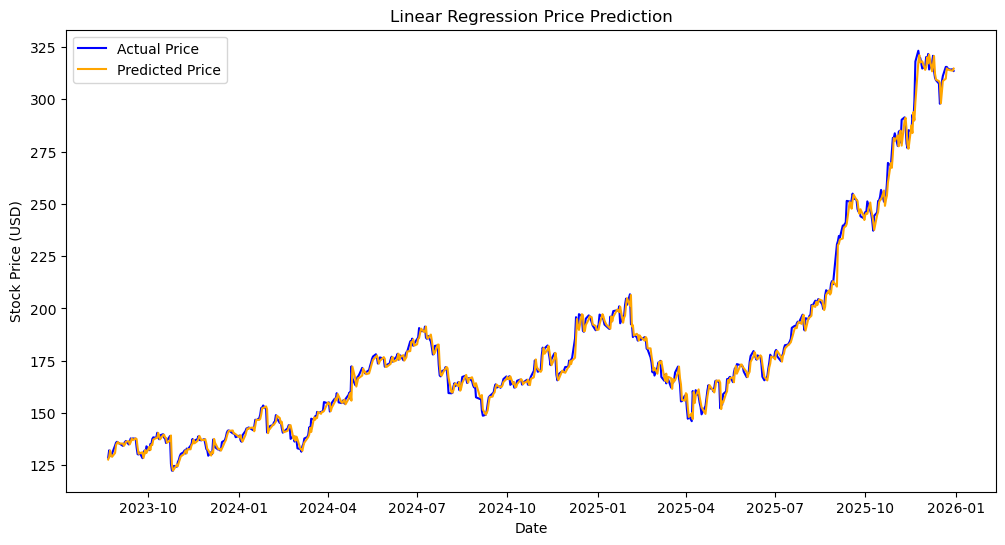

In [22]:
plt.figure(figsize=(12,6))

plt.plot(y_test_price.index, y_test_price.values, label="Actual Price", color="blue")
plt.plot(y_test_price.index, lr_predictions, label="Predicted Price",color="orange")

plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")

plt.title("Linear Regression Price Prediction")
plt.legend()
plt.show()

# 7. Evaluating direction accuracy

In [23]:
# Predicted price > today's price: stock goes UP
# Predicted price =< today's price: stock goes DOWN

# Force both to be flat 1D arrays before comparing
pred_vals = lr_predictions.ravel()
actual_closes = X_test_price["Close_GOOG"].values.ravel()

# This will now be shape (594,)
predicted_direction = (pred_vals > actual_closes).astype(int)


direction_accuracy = accuracy_score(y_test_dir, predicted_direction)
print(f"Directional accuracy: {direction_accuracy:.2%}")

Directional accuracy: 54.13%


In [24]:
print("Linear Regression confusion matrix:")
print(confusion_matrix(y_test_dir, predicted_direction))

Linear Regression confusion matrix:
[[154 103]
 [169 167]]


## Linear Regression Model Evaluation
The model shows a balanced directional accuracy of approximately 54.13%. While the price predictions (MAE/RMSE) are tight, the model is slightly more prone to False Negatives (169) than False Positives (103), suggesting it is cautious about predicting upward trends. The model is currently more likely to miss an upward move (predicting Down when it went Up) than it is to give a false alarm (predicting Up when it went Down).

# 8. Random Forest Regressor

In [25]:
rf_model = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42)

X_train_rf = X_train_price.drop(columns=["Close_GOOG"])
X_test_rf = X_test_price.drop(columns=["Close_GOOG"])

rf_model.fit(X_train_rf, y_train_price)

rf_predictions = rf_model.predict(X_test_rf)

rf_mae = mean_absolute_error(y_test_price, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test_price, rf_predictions))

print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")

Random Forest MAE: 36.01
Random Forest RMSE: 55.89


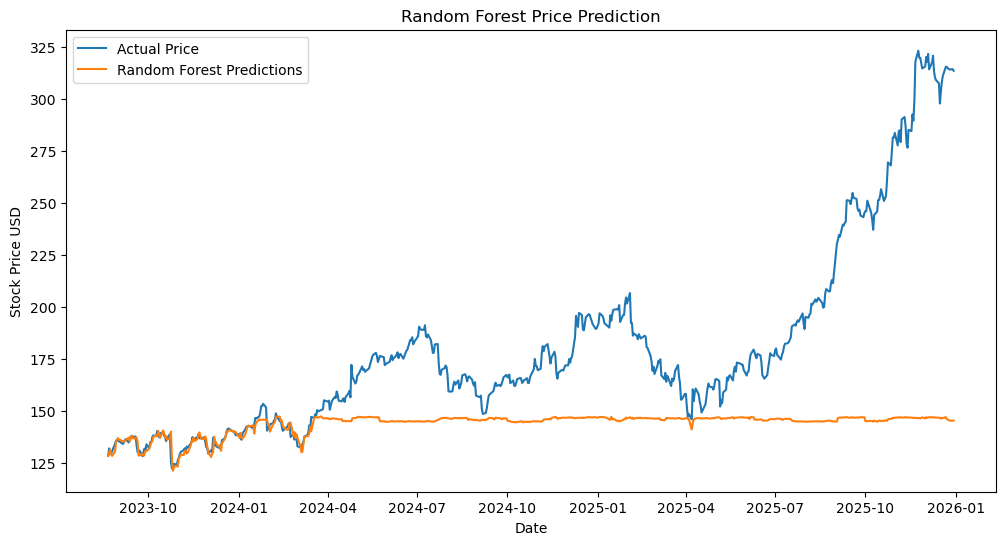

In [26]:
plt.figure(figsize=(12,6))

plt.plot(y_test_price.index, y_test_price.values, label="Actual Price")
plt.plot(y_test_price.index, rf_predictions, label="Random Forest Predictions")

plt.xlabel("Date")
plt.ylabel("Stock Price USD")
plt.title("Random Forest Price Prediction")

plt.legend()

plt.show()

In [27]:
rf_pred_values = rf_predictions.ravel()

rf_direction = (rf_pred_values > actual_closes).astype(int)

rf_direction_accuracy = accuracy_score(y_test_dir, rf_direction)

print(f"Random Forest Regressor Directional Accuracy: {rf_direction_accuracy:.2%}")

Random Forest Regressor Directional Accuracy: 45.36%


In [28]:
rf_cm = confusion_matrix(y_test_dir, rf_direction)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[227  30]
 [294  42]]


## Random Forest Regressor Model Evaluation
The Random Forest model struggled significantly with price prediction, yielding a high MAE (35.90) and RMSE (55.80). This performance gap compared to Linear Regression is primarily due to the inability of tree-based methods to extrapolate; because the stock price reached new historical highs, the model was forced to "flatline" its predictions at the highest values seen in the training data.

In terms of market direction, the model achieved a directional accuracy of ~47%. The confusion matrix shows a heavy bias toward False Negatives (292), where the model predicted a downward move for days that actually went Up. This confirms that while the model is good at identifying "Down" days (233 correct), it is currently failing to capture the upward momentum of the stock, largely because the price levels are outside its known training range.

# 9. Random Forest Classifier

In [29]:
rf_classifier = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42)

rf_classifier.fit(X_train_dir, y_train_dir)

rf_dir_predictions = rf_classifier.predict(X_test_dir)

rf_dir_accuracy = accuracy_score(y_test_dir, rf_dir_predictions)

print(f"Random forest classifier directional accuracy {rf_dir_accuracy:.2%}")

Random forest classifier directional accuracy 45.19%


In [30]:
rf_dir_cm = confusion_matrix(y_test_dir, rf_dir_predictions)
print("Random forest classifier confusion matrix")
print(rf_dir_cm)

Random forest classifier confusion matrix
[[210  47]
 [278  58]]


In [31]:
feature_importances = rf_classifier.feature_importances_

feature_names = X_train_dir.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df)

           Feature  Importance
4      Volume_GOOG    0.072123
18    Return_Lag3_    0.069291
15         RSI_14_    0.067318
17    Return_Lag2_    0.066664
16    Return_Lag1_    0.065324
10  Volatility_20_    0.062320
5    Price_Change_    0.056659
9    Daily_Return_    0.056476
8        SMA_diff_    0.053401
14     Lag5_Close_    0.051344
7           SMA50_    0.047127
6           SMA20_    0.044267
12     Lag2_Close_    0.043721
11     Lag1_Close_    0.042097
0       Close_GOOG    0.041338
2         Low_GOOG    0.041278
3        Open_GOOG    0.040271
13     Lag3_Close_    0.040179
1        High_GOOG    0.038802


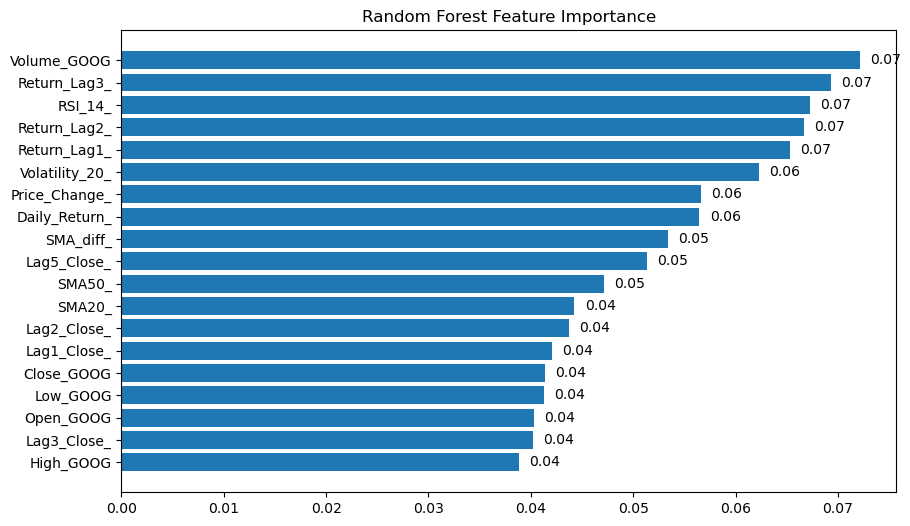

In [32]:
plt.figure(figsize=(10,6))

plt.barh(importance_df["Feature"], importance_df["Importance"])

plt.title("Random Forest Feature Importance")

for i, v in enumerate(importance_df["Importance"]):
    plt.text(v + 0.001, i, f'{v:.2f}', va='center')

plt.gca().invert_yaxis()

plt.show()

The feature importance scores are relatively balanced, with only a small margin of 0.03 separating the highest-ranked feature (0.07) from the lowest (0.04). This indicates that the model utilizes a broad mix of price, volume, and technical indicators rather than being dominated by one specific predictor.

The most influential features were lagged returns and momentum indicators such as RSI, suggesting that short-term price momentum contains limited predictive information.

# 10. ARIMA

In [42]:
ts_data = X["Close_GOOG"]

ts_data.index = pd.to_datetime(ts_data.index)
ts_data = ts_data.asfreq('B').ffill()
train_size = int(len(ts_data) * 0.8)

train_ts = ts_data[:train_size]
test_ts = ts_data[train_size:]

arima_model = ARIMA(train_ts, order=(2,1,0))
arima_fit = arima_model.fit()

arima_predictions = arima_fit.forecast(steps=len(test_ts))

arima_mae = mean_absolute_error(test_ts, arima_predictions)
arima_rmse = np.sqrt(mean_squared_error(test_ts, arima_predictions))

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)

ARIMA MAE: 50.96390509320486
ARIMA RMSE: 67.90796458747201


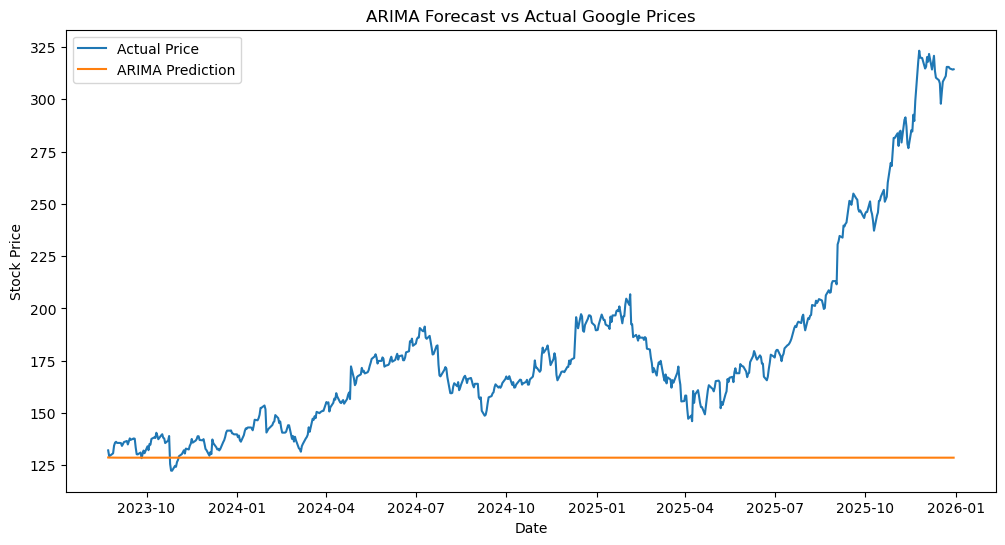

In [38]:
plt.figure(figsize=(12,6))

plt.plot(test_ts.index, test_ts, label="Actual Price")
plt.plot(test_ts.index, arima_predictions, label="ARIMA Prediction")

plt.title("ARIMA Forecast vs Actual Google Prices")
plt.xlabel("Date")
plt.ylabel("Stock Price")

plt.legend()

plt.show()

In [44]:
history = list(train_ts)
rolling_predictions = []

# Loop through every time step in the test set
for t in range(len(test_ts)):
    model = ARIMA(history, order=(2,1,0))
    model_fit = model.fit()
    
    # Predict only the next single step
    output = model_fit.forecast()
    yhat = output[0]
    rolling_predictions.append(yhat)
    
    # Add the actual observation to history for the next loop
    obs = test_ts.iloc[t]
    history.append(obs)

rolling_mae = mean_absolute_error(test_ts, rolling_predictions)
rolling_rmse = np.sqrt(mean_squared_error(test_ts, rolling_predictions))
print("Rolling ARIMA MAE:", rolling_mae)
print("Rolling ARIMA RMSE:", rolling_rmse)

Rolling ARIMA MAE: 2.325551814101124
Rolling ARIMA RMSE: 3.373218926673218


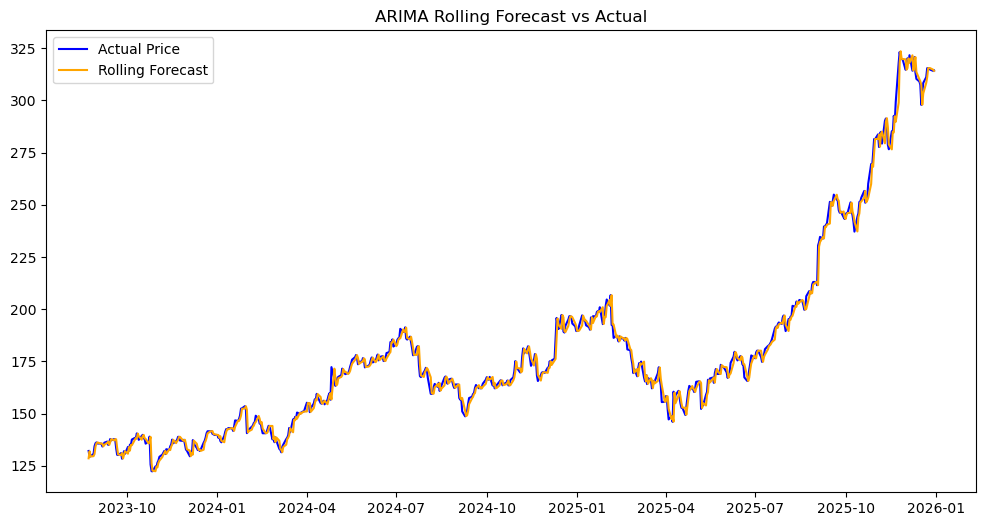

In [48]:
plt.figure(figsize=(12,6))
plt.plot(test_ts.index, test_ts, label='Actual Price', color='blue')
plt.plot(test_ts.index, rolling_predictions, label='Rolling Forecast', color="orange")
plt.title('ARIMA Rolling Forecast vs Actual')
plt.legend()
plt.show()